# Credit Risk Early Warning System

This notebook uses LendingClub loans to estimate default risk and identify loans whose risk increases over time.

## Key findings

- The baseline model ranks risk well: ROC-AUC is 0.729 and average precision is 0.406 on resolved 2015 loans.
- Observed default rises from 5.5% in the lowest-risk group to 42.3% in the highest-risk group.
- The models understate default in higher-risk groups, so the scores need further calibration before operational use.
- 60-month loans are materially riskier than 36-month loans.
- The horizon and watchlist results are useful prototypes, but event timing and economic assumptions still need validation.

In [1]:
import os
from pathlib import Path

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt


In [2]:
path = Path(os.environ.get(
    "CREDIT_RISK_DATA",
    "data/accepted_2007_to_2018Q4.csv.gz"
))
if not path.exists():
    raise FileNotFoundError(
        f"Dataset not found at {path}. Set CREDIT_RISK_DATA to the CSV.gz path."
    )
df = pd.read_csv(path, low_memory=False)
df = df.dropna(subset=["loan_status", "loan_amnt"]).copy()
df["loan_status"].value_counts(dropna = False)


loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

In [3]:
good_status = [
    "Fully Paid", 
    "Does not meet the credit policy. Status:Fully Paid"
]

bad_status = [
    "Charged Off", 
    "Does not meet the credit policy. Status:Charged Off", 
    "Default"
]

#Remove rows, with loan status column not containing one of above status
df_model = df[df["loan_status"].isin(good_status + bad_status)].copy()
#define new column "default", if user's loan_status is in bad_status, 
df_model["default"] = df_model["loan_status"].isin(bad_status).astype(int)



In [4]:
features = [
    "loan_amnt",
    "term",
    "int_rate",
    "installment",
    "grade",
    "sub_grade",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "purpose",
    "dti",
    "delinq_2yrs",
    "fico_range_low",
    "fico_range_high",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "issue_d"
]

df_model = df_model[features + ["default"]].copy()


In [5]:
df_model.info() #Type per Column 

<class 'pandas.DataFrame'>
Index: 1348099 entries, 0 to 2260697
Data columns (total 23 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   loan_amnt            1348099 non-null  float64
 1   term                 1348099 non-null  str    
 2   int_rate             1348099 non-null  float64
 3   installment          1348099 non-null  float64
 4   grade                1348099 non-null  str    
 5   sub_grade            1348099 non-null  str    
 6   emp_length           1269549 non-null  str    
 7   home_ownership       1348099 non-null  str    
 8   annual_inc           1348095 non-null  float64
 9   verification_status  1348099 non-null  str    
 10  purpose              1348099 non-null  str    
 11  dti                  1347725 non-null  float64
 12  delinq_2yrs          1348070 non-null  float64
 13  fico_range_low       1348099 non-null  float64
 14  fico_range_high      1348099 non-null  float64
 15  inq_last_6mths

In [6]:
# Make a clean working copy
data = df_model.copy()

# Clean term: "36 months" -> 36
data["term"] = (
    data["term"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(float)
)

# Clean issue date: "Dec-2015" -> datetime
data["issue_d"] = pd.to_datetime(data["issue_d"], format="%b-%Y", errors="coerce")

# Create issue year and issue month
data["issue_year"] = data["issue_d"].dt.year
data["issue_month"] = data["issue_d"].dt.month

# Drop the original date column after extracting useful parts
data = data.drop(columns=["issue_d"])

data.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,default,issue_year,issue_month
0,3600.0,36.0,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,...,679.0,1.0,7.0,0.0,2765.0,29.7,13.0,0,2015,12
1,24700.0,36.0,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,...,719.0,4.0,22.0,0.0,21470.0,19.2,38.0,0,2015,12
2,20000.0,60.0,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,...,699.0,0.0,6.0,0.0,7869.0,56.2,18.0,0,2015,12
4,10400.0,60.0,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Source Verified,...,699.0,3.0,12.0,0.0,21929.0,64.5,35.0,0,2015,12
5,11950.0,36.0,13.44,405.18,C,C3,4 years,RENT,34000.0,Source Verified,...,694.0,0.0,5.0,0.0,8822.0,68.4,6.0,0,2015,12


In [7]:
from sklearn.impute import SimpleImputer

X = data.drop(columns=["default"])
y = data["default"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)
df_model.isna().mean() #Mask over entire data, T/F values, then average over columns


/var/folders/2b/4kj7yr012f33kbb48k_dvj480000gn/T/ipykernel_65190/1349199873.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


loan_amnt              0.000000
term                   0.000000
int_rate               0.000000
installment            0.000000
grade                  0.000000
sub_grade              0.000000
emp_length             0.058267
home_ownership         0.000000
annual_inc             0.000003
verification_status    0.000000
purpose                0.000000
dti                    0.000277
delinq_2yrs            0.000022
fico_range_low         0.000000
fico_range_high        0.000000
inq_last_6mths         0.000022
open_acc               0.000022
pub_rec                0.000022
revol_bal              0.000000
revol_util             0.000665
total_acc              0.000022
issue_d                0.000000
default                0.000000
dtype: float64

In [8]:
data["issue_year"].value_counts().sort_index()


year_summary = (
    data
    .groupby("issue_year")
    .agg(
        loans=("default", "size"),
        defaults=("default", "sum"),
        default_rate=("default", "mean")
    )
    .reset_index()
)

term_year_summary = (
    data
    .groupby(["issue_year", "term"])
    .agg(
        loans=("default", "size"),
        default_rate=("default", "mean")
    )
    .reset_index()
)

term_year_summary


,issue_year,term,loans,default_rate
0,2007,36.0,603,0.262023
1,2008,36.0,2393,0.207271
2,2009,36.0,5281,0.136906
3,2010,36.0,9156,0.109218
4,2010,60.0,3381,0.223898
5,2011,36.0,14101,0.106305
6,2011,60.0,7620,0.235958
7,2012,36.0,43470,0.135795
8,2012,60.0,9897,0.276953
9,2013,36.0,100422,0.123260


In [9]:
train = data[data["issue_year"] <= 2014].copy()
test = data[data["issue_year"] == 2015].copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("Train default rate:", train["default"].mean())
print("Test default rate:", test["default"].mean())

Train shape: (453809, 24)
Test shape: (375546, 24)
Train default rate: 0.17025003911337147
Test default rate: 0.20185010624530683


In [10]:
print("Train default rate by term:")
print(train.groupby("term")["default"].mean())

print("\nTest default rate by term:")
print(test.groupby("term")["default"].mean())

Train default rate by term:
term
36.0    0.131576
60.0    0.283120
Name: default, dtype: float64

Test default rate by term:
term
36.0    0.148863
60.0    0.363943
Name: default, dtype: float64


In [11]:
drop_cols = ["default", "issue_year"]
x_train = train.drop(columns = drop_cols)
y_train = train["default"]

x_test = test.drop(columns = drop_cols)
y_test = test["default"]

x_train.head()



,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,issue_month
1117060,10400.0,36.0,6.99,321.08,A,A3,8 years,MORTGAGE,58000.0,Not Verified,...,0.0,710.0,714.0,2.0,17.0,0.0,6133.0,31.6,36.0,12
1117061,15000.0,60.0,12.39,336.64,C,C1,10+ years,RENT,78000.0,Source Verified,...,0.0,750.0,754.0,0.0,6.0,0.0,138008.0,29.0,17.0,12
1117062,9600.0,36.0,13.66,326.53,C,C3,10+ years,RENT,69000.0,Source Verified,...,0.0,680.0,684.0,0.0,12.0,0.0,16388.0,59.4,44.0,12
1117063,7650.0,36.0,13.66,260.20,C,C3,< 1 year,RENT,50000.0,Source Verified,...,0.0,685.0,689.0,1.0,11.0,0.0,16822.0,91.9,20.0,12
1117065,21425.0,60.0,15.59,516.36,D,D1,6 years,RENT,63800.0,Source Verified,...,0.0,685.0,689.0,0.0,10.0,0.0,16374.0,76.2,35.0,12


In [12]:
log_reg = LogisticRegression(max_iter= 1000, n_jobs=-1)

clf = Pipeline(steps = [("preprocess", preprocess), ("model", log_reg)])
clf.fit(x_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['loan_amnt','term','int_rate',...,'revol_util','total_acc','issue_month']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all

In [13]:
pd_test = clf.predict_proba(x_test)[:, 1]
pd_test[:10]

array([0.13814523, 0.27484808, 0.16812723, 0.32608116, 0.17667682,
       0.05349047, 0.08776551, 0.06029981, 0.14402132, 0.14580073])

## Baseline performance

We evaluate whether the model ranks defaulted loans above non-defaulted loans and concentrates defaults among its highest scores.

In [14]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc = roc_auc_score(y_test, pd_test)
avg_precision = average_precision_score(y_test, pd_test)

print("ROC-AUC:", roc_auc)
print("Average Precision:", avg_precision)

ROC-AUC: 0.7293422678578244
Average Precision: 0.4061532994185803


We found a ROC-AUC of 0.729, so the model ranks a defaulted loan above a non-defaulted loan about 73% of the time. Average precision is 0.406 versus a 20.2% default rate, showing roughly twice the concentration of a random ranking.

In [15]:
test_results = x_test.copy()
test_results["actual_pd"] = y_test
test_results["predicted_pd"] = pd_test

test_results.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,issue_month,actual_pd,predicted_pd
0,3600.0,36.0,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,...,679.0,1.0,7.0,0.0,2765.0,29.7,13.0,12,0,0.138145
1,24700.0,36.0,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,...,719.0,4.0,22.0,0.0,21470.0,19.2,38.0,12,0,0.274848
2,20000.0,60.0,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,...,699.0,0.0,6.0,0.0,7869.0,56.2,18.0,12,0,0.168127
4,10400.0,60.0,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Source Verified,...,699.0,3.0,12.0,0.0,21929.0,64.5,35.0,12,0,0.326081
5,11950.0,36.0,13.44,405.18,C,C3,4 years,RENT,34000.0,Source Verified,...,694.0,0.0,5.0,0.0,8822.0,68.4,6.0,12,0,0.176677


In [16]:
test_results["risk_band"] = pd.qcut(
    test_results["predicted_pd"], q = 5, labels = ["Very low", "Low", "Medium", "High", "Very High"]
)

risk_band_summary = test_results.groupby("risk_band").agg(
    n_loans = ("predicted_pd", "count"),
    average_predicted_default_rate =("predicted_pd", "mean"), 
    actual_default_rate = ("actual_pd", "mean")
    ).reset_index()

risk_band_summary["calibration_gap"] = (
    risk_band_summary["actual_default_rate"] 
    - risk_band_summary["average_predicted_default_rate"]
)

risk_band_summary["actual_to_predicted_ratio"] = (
    risk_band_summary["actual_default_rate"] 
    / risk_band_summary["average_predicted_default_rate"]
)

risk_band_summary

risk_band_summary

,risk_band,n_loans,average_predicted_default_rate,actual_default_rate,calibration_gap,actual_to_predicted_ratio
0,Very low,75110,0.054025,0.054853,0.000828,1.015322
1,Low,75109,0.106002,0.110546,0.004544,1.042867
2,Medium,75109,0.153794,0.172962,0.019168,1.124636
3,High,75109,0.214578,0.247653,0.033075,1.154141
4,Very High,75109,0.343925,0.423238,0.079313,1.230611


Observed default rises from 5.5% in the lowest-risk fifth to 42.3% in the highest-risk fifth. The ranking is useful, but the highest group defaults 7.9 percentage points more often than predicted, showing material underestimation at the top end.

In [17]:
term_band_summary = (
    test_results
    .groupby(["term", "risk_band"], observed=True)
    .agg(
        n_loans=("predicted_pd", "count"),
        average_predicted_default_rate=("predicted_pd", "mean"),
        actual_default_rate=("actual_pd", "mean")
    )
)

term_band_summary["calibration_gap"] = (
    term_band_summary["actual_default_rate"] 
    - term_band_summary["average_predicted_default_rate"]
)

term_band_summary["actual_to_predicted_ratio"] = (
    term_band_summary["actual_default_rate"] 
    / term_band_summary["average_predicted_default_rate"]
)

term_band_summary

n_loans  average_predicted_default_rate  actual_default_rate  \
term risk_band                                                                 
36.0 Very low     73892                        0.053875             0.053862   
     Low          70256                        0.105765             0.108916   
     Medium       65551                        0.153455             0.169852   
     High         55183                        0.212520             0.240853   
     Very High    18144                        0.296176             0.334821   
60.0 Very low      1218                        0.063104             0.114943   
     Low           4853                        0.109439             0.134144   
     Medium        9558                        0.156118             0.194288   
     High         19926                        0.220278             0.266486   
     Very High    56965                        0.359134             0.451400   

                calibration_gap  actual_to_predicted_ratio  
term risk_band                                              
36.0 Very low         -0.000013                   0.999757  
     Low               0.003151                   1.029796  
     Medium            0.016398                   1.106856  
     High              0.028333                   1.133321  
     Very High         0.038645                   1.130481  
60.0 Very low          0.051839                   1.821482  
     Low               0.024705                   1.225743  
     Medium            0.038170                   1.244493  
     High              0.046208                   1.209771  
     Very High         0.092266                   1.256913

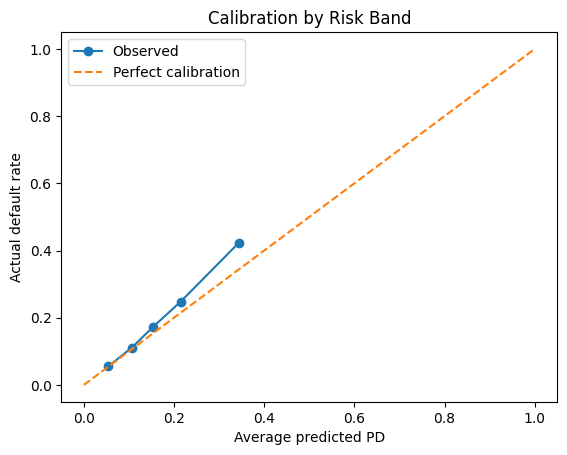

In [18]:
plt.plot(
    risk_band_summary["average_predicted_default_rate"],
    risk_band_summary["actual_default_rate"],
    marker="o",
    label="Observed"
)
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

plt.xlabel("Average predicted PD")
plt.ylabel("Actual default rate")
plt.title("Calibration by Risk Band")
plt.legend()
plt.show()

### Performance by loan term

We check whether the overall result holds within 36- and 60-month loans.

In [19]:
for term_value in sorted(test_results["term"].dropna().unique()):
    subset = test_results[test_results["term"] == term_value]

    auc = roc_auc_score(subset["actual_pd"], subset["predicted_pd"])
    ap = average_precision_score(subset["actual_pd"], subset["predicted_pd"])
    default_rate = subset["actual_pd"].mean()
    
    print(f"Term: {term_value}")
    print(f"Loans: {len(subset):,}")
    print(f"Default rate: {default_rate:.3f}")
    print(f"ROC-AUC: {auc:.3f}")
    print(f"Average precision: {ap:.3f}")
    print()


Term: 36.0
Loans: 283,026
Default rate: 0.149
ROC-AUC: 0.688
Average precision: 0.263

Term: 60.0
Loans: 92,520
Default rate: 0.364
ROC-AUC: 0.669
Average precision: 0.515



Within-term ROC-AUC falls to 0.688 for 36-month loans and 0.669 for 60-month loans. This shows that loan term drives part of the overall separation, while ranking within each term is weaker.

## Expected loss

Expected loss is calculated as probability of default (PD) x loss given default (LGD) x exposure at default (EAD). The analysis uses an illustrative 60% LGD.

In [20]:
lgd = 0.60
test_results["ead"] = test_results["loan_amnt"]
test_results["expected_loss"] = test_results["ead"] * lgd * test_results["predicted_pd"]

portfolio_expected_loss = test_results["expected_loss"].sum()
portfolio_exposure = test_results["loan_amnt"].sum()
portfolio_expected_loss_rate = portfolio_expected_loss/portfolio_exposure

portfolio_summary = pd.DataFrame([
{
        "Expected Loss": portfolio_expected_loss, 
        "Exposure": portfolio_exposure,
        "Expected Loss Rate": portfolio_expected_loss_rate
    }
]
    
)
portfolio_summary

,Expected Loss,Exposure,Expected Loss Rate
0,6.073378e+08,5.498601e+09,0.110453


In [21]:


term_el_summary = (
    test_results
    .groupby("term")
    .agg(
        loans=("expected_loss", "size"),
        exposure=("ead", "sum"),
        average_pd_rate = ("predicted_pd", "mean"),
        average_true_pd_rate = ("actual_pd", "mean"),
        expected_loss=("expected_loss", "sum")
    )
    .reset_index()
)

term_el_summary["expected_loss_rate"] = (
    term_el_summary["expected_loss"] / term_el_summary["exposure"]
)

term_el_summary


,term,loans,exposure,average_pd_rate,average_true_pd_rate,expected_loss,expected_loss_rate
0,36.0,283026,3.624301e+09,0.136284,0.148863,2.849613e+08,0.078625
1,60.0,92520,1.874300e+09,0.291261,0.363943,3.223765e+08,0.171998


We found that 60-month loans have lower exposure ($1.87B versus $3.62B) but higher expected loss ($322M versus $285M). Their observed default rate is also much higher: 36.4% versus 14.9%.

In [22]:
grade_el_summary = (
    test_results
    .groupby("grade")
    .agg(
        loans=("loan_amnt", "count"),
        exposure=("ead", "sum"),
        avg_pd=("predicted_pd", "mean"),
        actual_default_rate=("actual_pd", "mean"),
        expected_loss=("expected_loss", "sum")
    )
    .reset_index()
)

grade_el_summary["expected_loss_rate"] = (
    grade_el_summary["expected_loss"] / grade_el_summary["exposure"]
)

grade_el_summary.sort_values("expected_loss_rate")

,grade,loans,exposure,avg_pd,actual_default_rate,expected_loss,expected_loss_rate
0,A,71890,1.049132e+09,0.059347,0.055432,3.678010e+07,0.035058
1,B,106916,1.457073e+09,0.121818,0.130280,1.070264e+08,0.073453
2,C,104616,1.459863e+09,0.193099,0.224163,1.731358e+08,0.118597
3,D,53480,8.158117e+08,0.265816,0.322737,1.342786e+08,0.164595
4,E,28536,5.149434e+08,0.345079,0.419050,1.082085e+08,0.210137
5,F,8212,1.632620e+08,0.385689,0.510716,3.813049e+07,0.233554
6,G,1896,3.851572e+07,0.420447,0.541667,9.778005e+06,0.253870


The baseline uses logistic regression with origination-time borrower and loan features. Training on vintages through 2014 and testing on 2015 provides an out-of-time assessment.

## Nonlinear model comparison

We compare logistic regression with histogram gradient boosting to test whether nonlinear relationships improve risk ranking.

In [23]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier

numeric_features = x_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = x_train.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Numeric features: ['loan_amnt', 'term', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc']
Categorical features: ['grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose']


/var/folders/2b/4kj7yr012f33kbb48k_dvj480000gn/T/ipykernel_65190/514183690.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = x_train.select_dtypes(include=["object"]).columns.tolist()


In [24]:
gb_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=200,
    max_leaf_nodes=31,
    min_samples_leaf=100,
    l2_regularization=0.1,
    random_state=42
)

gb_clf = Pipeline(steps=[
    ("preprocess", preprocess_tree),
    ("model", gb_model)
])

gb_clf.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['loan_amnt','term','int_rate',...,'revol_util','total_acc','issue_month']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all

In [25]:
gb_pd_test = gb_clf.predict_proba(x_test)[:, 1]

gb_pd_test[:10]

array([0.11576985, 0.37425788, 0.15732082, 0.28036965, 0.19545138,
       0.06034399, 0.09151093, 0.04403434, 0.11666997, 0.11224341])

In [26]:

gb_roc_auc = roc_auc_score(y_test, gb_pd_test)
gb_avg_precision = average_precision_score(y_test, gb_pd_test)

print("Gradient Boosting ROC-AUC:", gb_roc_auc)
print("Gradient Boosting Average Precision:", gb_avg_precision)

Gradient Boosting ROC-AUC: 0.7325022647544008
Gradient Boosting Average Precision: 0.40929211688750117


In [27]:
model_comparison = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "roc_auc": roc_auc,
        "average_precision": avg_precision
    },
    {
        "model": "Hist Gradient Boosting",
        "roc_auc": gb_roc_auc,
        "average_precision": gb_avg_precision
    }
])

model_comparison

,model,roc_auc,average_precision
0,Logistic Regression,0.729342,0.406153
1,Hist Gradient Boosting,0.732502,0.409292


In [28]:
gb_results = x_test.copy()
gb_results["predicted_pd"] = gb_pd_test
gb_results["actual_pd"] = y_test

In [29]:
gb_results["risk_band"] = pd.qcut(
    gb_results["predicted_pd"], q = 5, labels = ["Very Low", "Low", "Medium", "High", "Very High"]
)

gb_risk_band_summary = gb_results.groupby("risk_band").agg(
    loans = ("predicted_pd", "count"), 
    average_predicted_default_rate = ("predicted_pd", "mean"),
    actual_default_rate = ("actual_pd", "mean")
).reset_index()
gb_risk_band_summary["calibration_gap"] = gb_risk_band_summary["actual_default_rate"] - gb_risk_band_summary["average_predicted_default_rate"]
gb_risk_band_summary

,risk_band,loans,average_predicted_default_rate,actual_default_rate,calibration_gap
0,Very Low,75110,0.047359,0.052403,0.005044
1,Low,75109,0.096109,0.110945,0.014836
2,Medium,75109,0.146963,0.169527,0.022564
3,High,75109,0.212985,0.250809,0.037824
4,Very High,75109,0.355240,0.425568,0.070328


In [30]:
lr_band = risk_band_summary.reset_index().copy()

# If risk_band is the index in your current table, this brings it back as a column.
if "risk_band" not in lr_band.columns:
    lr_band = lr_band.rename(columns={"index": "risk_band"})

lr_band = lr_band.rename(columns={
    "n_loans": "loans",
    "average_predicted_default_rate": "avg_predicted_pd"
})

gb_band = gb_risk_band_summary.copy().rename(columns={
    "n_loans": "loans",
    "average_predicted_default_rate": "avg_predicted_pd"
})

lr_band["model"] = "Logistic Regression"
gb_band["model"] = "Hist Gradient Boosting"

band_comparison = pd.concat([
    lr_band[["model", "risk_band", "loans", "avg_predicted_pd", "actual_default_rate", "calibration_gap"]],
    gb_band[["model", "risk_band", "loans", "avg_predicted_pd", "actual_default_rate", "calibration_gap"]]
])

band_comparison

,model,risk_band,loans,avg_predicted_pd,actual_default_rate,calibration_gap
0,Logistic Regression,Very low,75110,0.054025,0.054853,0.000828
1,Logistic Regression,Low,75109,0.106002,0.110546,0.004544
2,Logistic Regression,Medium,75109,0.153794,0.172962,0.019168
3,Logistic Regression,High,75109,0.214578,0.247653,0.033075
4,Logistic Regression,Very High,75109,0.343925,0.423238,0.079313
0,Hist Gradient Boosting,Very Low,75110,0.047359,0.052403,0.005044
1,Hist Gradient Boosting,Low,75109,0.096109,0.110945,0.014836
2,Hist Gradient Boosting,Medium,75109,0.146963,0.169527,0.022564
3,Hist Gradient Boosting,High,75109,0.212985,0.250809,0.037824
4,Hist Gradient Boosting,Very High,75109,0.355240,0.425568,0.070328


### Calibration comparison

Risk-band calibration shows whether predicted probabilities match observed default rates.

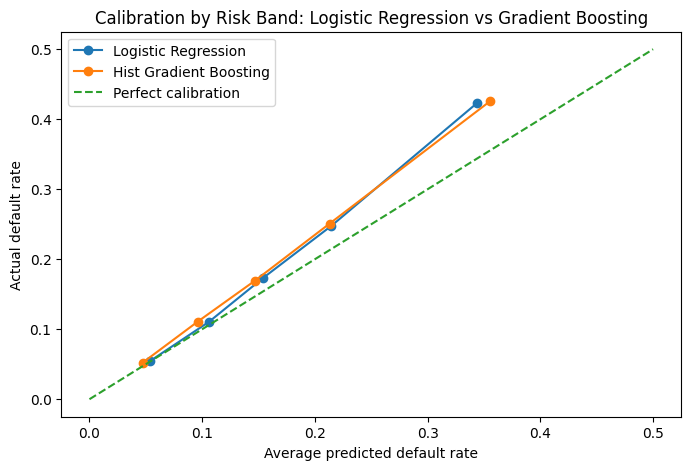

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    risk_band_summary["average_predicted_default_rate"],
    risk_band_summary["actual_default_rate"],
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    gb_risk_band_summary["average_predicted_default_rate"],
    gb_risk_band_summary["actual_default_rate"],
    marker="o",
    label="Hist Gradient Boosting"
)

plt.plot([0, 0.5], [0, 0.5], linestyle="--", label="Perfect calibration")

plt.xlabel("Average predicted default rate")
plt.ylabel("Actual default rate")
plt.title("Calibration by Risk Band: Logistic Regression vs Gradient Boosting")
plt.legend()
plt.show()

Gradient boosting improves ROC-AUC only from 0.729 to 0.733 and average precision from 0.406 to 0.409. Both models still underpredict higher-risk groups, so calibration is a larger issue than model complexity.

In [32]:
time_features = [
    "loan_amnt",
    "term",
    "int_rate",
    "installment",
    "grade",
    "sub_grade",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "purpose",
    "dti",
    "delinq_2yrs",
    "fico_range_low",
    "fico_range_high",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "issue_d",
    "last_pymnt_d",
    "loan_status"
]

time_df = df[time_features].copy()

time_df.dropna(subset = ["loan_status", "loan_amnt", "issue_d"]).copy()

time_df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,issue_d,last_pymnt_d,loan_status
0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,...,679.0,1.0,7.0,0.0,2765.0,29.7,13.0,Dec-2015,Jan-2019,Fully Paid
1,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,...,719.0,4.0,22.0,0.0,21470.0,19.2,38.0,Dec-2015,Jun-2016,Fully Paid
2,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,...,699.0,0.0,6.0,0.0,7869.0,56.2,18.0,Dec-2015,Jun-2017,Fully Paid
3,35000.0,60 months,14.85,829.90,C,C5,10+ years,MORTGAGE,110000.0,Source Verified,...,789.0,0.0,13.0,0.0,7802.0,11.6,17.0,Dec-2015,Feb-2019,Current
4,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Source Verified,...,699.0,3.0,12.0,0.0,21929.0,64.5,35.0,Dec-2015,Jul-2016,Fully Paid


## Horizon-specific default risk

The next models estimate default within 12, 24, and 36 months. Because no exact default date is available, `last_pymnt_d` is an approximate event-time proxy.

In [33]:
time_df["issue_d"] = pd.to_datetime(
    time_df["issue_d"], 
    format = "%b-%Y", 
    errors = "coerce"
)
time_df["last_pymnt_d"] = pd.to_datetime(
    time_df["last_pymnt_d"], 
    format = "%b-%Y", 
    errors = "coerce"
)
time_df = time_df.dropna(subset = ["issue_d"]).copy()


def month_dif(start, end): 
    return ((end.dt.year) - (start.dt.year)) * 12 + (end.dt.month - start.dt.month)

time_df["months_observed"] = month_dif(time_df["issue_d"], time_df["last_pymnt_d"])
time_df[["issue_d", "last_pymnt_d", "months_observed"]].head()

,issue_d,last_pymnt_d,months_observed
0,2015-12-01,2019-01-01,37.0
1,2015-12-01,2016-06-01,6.0
2,2015-12-01,2017-06-01,18.0
3,2015-12-01,2019-02-01,38.0
4,2015-12-01,2016-07-01,7.0


In [34]:
time_df["months_observed"].describe()


count    2.258241e+06
mean     1.955459e+01
std      1.238392e+01
min      0.000000e+00
25%      9.000000e+00
50%      1.700000e+01
75%      2.900000e+01
max      7.000000e+01
Name: months_observed, dtype: float64

A horizon label equals 1 when a loan is observed to default within that window and 0 otherwise.

In [35]:
time_df["eventual_default"] = time_df["loan_status"].isin(bad_status).astype(int)
time_df["fully_paid"] = time_df["loan_status"].isin(good_status).astype(int)


In [36]:
def make_horizon_dataset(df, horizon):
    temp = df.copy()
    
    target_col = f"default_{horizon}m"
    
    # Default within horizon:
    # charged off/default and observed event proxy is within horizon
    temp[target_col] = (
        (temp["eventual_default"] == 1)
        & (temp["months_observed"] <= horizon)
    ).astype(int)
    
    # Valid rows:
    # 1. default happened within the horizon
    # 2. loan was observed at least horizon months
    # 3. loan was fully paid before horizon, so it safely did not default
    valid = (
        (temp[target_col] == 1)
        | (temp["months_observed"] >= horizon)
        | (temp["fully_paid"] == 1)
    )
    
    temp = temp[valid].copy()
    
    return temp


data_12m = make_horizon_dataset(time_df, 12)
data_24m = make_horizon_dataset(time_df, 24)
data_36m = make_horizon_dataset(time_df, 36)

for horizon, horizon_df in [(12, data_12m), (24, data_24m), (36, data_36m)]: 
    target = f"default_{horizon}m"
    print(f"{horizon}- month dataset")
    print("Rows:", len(horizon_df))
    print("Default Rate", horizon_df[target].mean())
    


12- month dataset
Rows: 1901296
Default Rate 0.06006902660080282
24- month dataset
Rows: 1592168
Default Rate 0.13471756749287764
36- month dataset
Rows: 1422033
Default Rate 0.18176090146993776


In [37]:
for horizon, horizon_df in [(12, data_12m), (24, data_24m), (36, data_36m)]:
    target = f"default_{horizon}m"
    
    print(f"{horizon}-month default rate by term")
    print(horizon_df.groupby("term")[target].mean())
    print()

12-month default rate by term
term
36 months    0.053477
60 months    0.076690
Name: default_12m, dtype: float64

24-month default rate by term
term
36 months    0.119175
60 months    0.174709
Name: default_24m, dtype: float64

36-month default rate by term
term
36 months    0.157614
60 months    0.244261
Name: default_36m, dtype: float64



Outcome and timing fields are excluded from model features to prevent information leakage.

In [38]:
def prepare_horizon_xy(horizon_df, horizon):
    target = f"default_{horizon}m"
    leakage_or_target_cols = [
        "loan_status",
        "last_pymnt_d",
        "months_observed",
        "eventual_default",
        "fully_paid",
        "default_12m",
        "default_24m",
        "default_36m"
    ]

    col_drop = [col for col in leakage_or_target_cols if col in horizon_df]
    X = horizon_df.drop(columns = col_drop)
    y = horizon_df[target]

    return X, y

In [39]:
def split_horizon_data(horizon_df, horizon, train_end_year = 2014, test_year = 2015):
    target = f"default_{horizon}m"
    temp = horizon_df.copy()
    temp["issue_year"] = temp["issue_d"].dt.year
    temp["issue_month"] = temp["issue_d"].dt.month

    train = temp[temp["issue_year"] <= train_end_year].copy()
    test = temp[temp["issue_year"] == test_year].copy()
    
    X_train, y_train = prepare_horizon_xy(train, horizon)
    X_test, y_test = prepare_horizon_xy(test,horizon)

    X_train = X_train.drop(columns=["issue_year", "issue_d"], errors="ignore")
    X_test = X_test.drop(columns=["issue_year", "issue_d"], errors="ignore")

    return X_train, X_test, y_train, y_test




In [40]:
X_train_12, X_test_12, y_train_12, y_test_12 = split_horizon_data(data_12m, 12)

print(X_train_12.shape)
print(X_test_12.shape)
print(y_train_12.mean())
print(y_test_12.mean())

(465969, 22)
(420801, 22)
0.051014123257126544
0.06047276503620476


In [41]:

numeric_features_12 = X_train_12.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features_12 = X_train_12.select_dtypes(include=["object"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

preprocess_12 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_12),
        ("cat", categorical_transformer, categorical_features_12)
    ]
)

/var/folders/2b/4kj7yr012f33kbb48k_dvj480000gn/T/ipykernel_65190/1385565608.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features_12 = X_train_12.select_dtypes(include=["object"]).columns.tolist()


In [42]:
hgb_12 = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=200,
    max_leaf_nodes=31,
    min_samples_leaf=100, 
    l2_regularization=0.1,
    random_state=42
)

model_12 = Pipeline(
    steps = [
        ("preprocess", preprocess_12),
        ("model", hgb_12)
    ] 
) 
model_12.fit(X_train_12, y_train_12)

pd_12_test = model_12.predict_proba(X_test_12)[:, 1]

auc_12 = roc_auc_score(y_test_12, pd_12_test)
ap_12 = average_precision_score(y_test_12, pd_12_test)

print("12-month ROC-AUC:", auc_12)
print("12-month Average Precision:", ap_12)
print("12-month test default rate:", y_test_12.mean())

12-month ROC-AUC: 0.7150037819246579
12-month Average Precision: 0.13637614769291073
12-month test default rate: 0.06047276503620476


In [43]:
def train_horizon_model(horizon_df, horizon):
    X_train_h, X_test_h, y_train_h, y_test_h = split_horizon_data(horizon_df, horizon)
    
    numeric_features = X_train_h.select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical_features = X_train_h.select_dtypes(include=["object"]).columns.tolist()
    
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])
    
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ])
    
    preprocess = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )
    
    model = HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=200,
        max_leaf_nodes=31,
        min_samples_leaf=100,
        l2_regularization=0.1,
        random_state=42
    )
    
    clf = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])
    
    clf.fit(X_train_h, y_train_h)
    
    pred_pd = clf.predict_proba(X_test_h)[:, 1]
    
    auc = roc_auc_score(y_test_h, pred_pd)
    ap = average_precision_score(y_test_h, pred_pd)
    default_rate = y_test_h.mean()
    
    results = X_test_h.copy()
    results["actual_default"] = y_test_h.values
    results["predicted_pd"] = pred_pd
    results["horizon"] = horizon
    
    return {
        "horizon": horizon,
        "model": clf,
        "auc": auc,
        "average_precision": ap,
        "default_rate": default_rate,
        "results": results
    }

In [44]:
horizon_12 = train_horizon_model(data_12m, 12)
horizon_24 = train_horizon_model(data_24m, 24)
horizon_36 = train_horizon_model(data_36m, 36)

/var/folders/2b/4kj7yr012f33kbb48k_dvj480000gn/T/ipykernel_65190/3774003867.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train_h.select_dtypes(include=["object"]).columns.tolist()
/var/folders/2b/4kj7yr012f33kbb48k_dvj480000gn/T/ipykernel_65190/3774003867.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence t

In [45]:
horizon_comparison = pd.DataFrame([
    {
        "horizon": horizon_12["horizon"],
        "roc_auc": horizon_12["auc"],
        "average_precision": horizon_12["average_precision"],
        "default_rate": horizon_12["default_rate"]
    },
    {
        "horizon": horizon_24["horizon"],
        "roc_auc": horizon_24["auc"],
        "average_precision": horizon_24["average_precision"],
        "default_rate": horizon_24["default_rate"]
    },
    {
        "horizon": horizon_36["horizon"],
        "roc_auc": horizon_36["auc"],
        "average_precision": horizon_36["average_precision"],
        "default_rate": horizon_36["default_rate"]
    }
])
horizon_comparison["ap_lift_vs_default_rate"] = (
    horizon_comparison["average_precision"] 
    / horizon_comparison["default_rate"]
)

horizon_comparison

,horizon,roc_auc,average_precision,default_rate,ap_lift_vs_default_rate
0,12,0.715004,0.136376,0.060473,2.255166
1,24,0.700922,0.256254,0.133194,1.923920
2,36,0.698207,0.316550,0.173703,1.822367


The 12-month model has the strongest ranking lift: 2.26 times the default-rate baseline, compared with 1.92 at 24 months and 1.82 at 36 months. This suggests origination data is most useful for identifying near-term risk.

In [46]:
def horizon_band_summary(horizon_result):
    results = horizon_result["results"].copy()
    horizon = horizon_result["horizon"]

    results["risk_band"] = pd.qcut(
        results["predicted_pd"],
        q=5,
        labels=["Very Low", "Low", "Medium", "High", "Very High"]
    )

    band = (
        results
        .groupby("risk_band", observed=True)
        .agg(
            loans=("predicted_pd", "count"),
            avg_predicted_pd=("predicted_pd", "mean"),
            actual_default_rate=("actual_default", "mean")
        )
        .reset_index()
    )

    band["calibration_gap"] = (
        band["actual_default_rate"] - band["avg_predicted_pd"]
    )

    band["horizon"] = horizon

    return band

band_12 = horizon_band_summary(horizon_12)
band_24 = horizon_band_summary(horizon_24)
band_36 = horizon_band_summary(horizon_36)

horizon_band_comparison = pd.concat([band_12, band_24, band_36])

horizon_band_comparison

,risk_band,loans,avg_predicted_pd,actual_default_rate,calibration_gap,horizon
0,Very Low,84161,0.012335,0.013676,0.001341,12
1,Low,84160,0.024221,0.029123,0.004902,12
2,Medium,84160,0.039121,0.049620,0.010498,12
3,High,84160,0.060480,0.075024,0.014544,12
4,Very High,84160,0.107089,0.134922,0.027832,12
0,Very Low,84161,0.031895,0.037191,0.005296,24
1,Low,84160,0.063728,0.077067,0.013340,24
2,Medium,84160,0.098287,0.117205,0.018918,24
3,High,84160,0.141496,0.167954,0.026458,24
4,Very High,84160,0.223905,0.266552,0.042647,24


In [47]:
common_2015 = data_36m.copy()
common_2015["issue_year"] = common_2015["issue_d"].dt.year
common_2015["issue_month"] = common_2015["issue_d"].dt.month
common_2015 = common_2015[common_2015["issue_year"] == 2015].copy()

In [48]:
for horizon in [12, 24, 36]: 
    target = f"actual_default_{horizon}m"
    common_2015[target] =((common_2015["eventual_default"] == 1) & (common_2015["months_observed"] <= horizon)).astype(int)

def make_scoring_features(df):
    leakage_or_target_cols = [
        "loan_status",
        "last_pymnt_d",
        "months_observed",
        "eventual_default",
        "fully_paid",
        "default_12m",
        "default_24m",
        "default_36m",
        "actual_default_12m",
        "actual_default_24m",
        "actual_default_36m"
    ]
    
    X = df.drop(columns=[c for c in leakage_or_target_cols if c in df.columns])
    
    # Create issue_month if needed
    if "issue_d" in X.columns:
        X["issue_month"] = X["issue_d"].dt.month
        X = X.drop(columns=["issue_d"], errors="ignore")
    
    X = X.drop(columns=["issue_year"], errors="ignore")
    
    return X

In [49]:
X_common = make_scoring_features(common_2015)

common_2015["pd_12m"] = horizon_12["model"].predict_proba(X_common)[:, 1]
common_2015["pd_24m"] = horizon_24["model"].predict_proba(X_common)[:, 1]
common_2015["pd_36m"] = horizon_36["model"].predict_proba(X_common)[:, 1]

In [50]:
common_2015["pd_24_less_than_12"] = common_2015["pd_24m"] < common_2015["pd_12m"]
common_2015["pd_36_less_than_24"] = common_2015["pd_36m"] < common_2015["pd_24m"]

print("24m PD < 12m PD rate:", common_2015["pd_24_less_than_12"].mean())
print("36m PD < 24m PD rate:", common_2015["pd_36_less_than_24"].mean())

24m PD < 12m PD rate: 0.00018300740585813836
36m PD < 24m PD rate: 0.0057564147660832616


In [51]:
common_2015["pd_12m_adj"] = common_2015["pd_12m"]

common_2015["pd_24m_adj"] = common_2015[["pd_12m", "pd_24m"]].max(axis=1)

common_2015["pd_36m_adj"] = common_2015[["pd_12m", "pd_24m", "pd_36m"]].max(axis=1)

## Risk acceleration

Risk acceleration measures how much predicted default risk increases from 12 months to 24 or 36 months.

In [52]:
common_2015["risk_accel_24m"] = (
    common_2015["pd_24m_adj"] - common_2015["pd_12m_adj"]
)

common_2015["risk_accel_36m"] = (
    common_2015["pd_36m_adj"] - common_2015["pd_12m_adj"]
)

In [53]:
common_2015["accel_band_24m"] = pd.qcut(
    common_2015["risk_accel_24m"], q = 5, labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

accel_24_summary = common_2015.groupby("accel_band_24m").agg(
    loans = ("accel_band_24m", "count"),
    avg_pd_12m=("pd_12m_adj", "mean"),
    avg_pd_24m=("pd_24m_adj", "mean"),
    avg_risk_accel_24m=("risk_accel_24m", "mean"),
    actual_default_12m=("actual_default_12m", "mean"),
    actual_default_24m=("actual_default_24m", "mean"),
    actual_default_36m=("actual_default_36m", "mean")
).reset_index()
accel_24_summary

,accel_band_24m,loans,avg_pd_12m,avg_pd_24m,avg_risk_accel_24m,actual_default_12m,actual_default_24m,actual_default_36m
0,Very Low,84150,0.014073,0.032854,0.018781,0.014118,0.038384,0.054367
1,Low,84149,0.027343,0.065308,0.037964,0.032324,0.079407,0.109995
2,Medium,84150,0.042422,0.099949,0.057527,0.051468,0.120856,0.160000
3,High,84149,0.061856,0.142093,0.080237,0.077826,0.170341,0.220050
4,Very High,84150,0.097544,0.219091,0.121548,0.126667,0.257065,0.324100


In [54]:
common_2015["accel_band_36m"] = pd.qcut(
    common_2015["risk_accel_36m"], q = 5, labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

accel_36_summary = common_2015.groupby("accel_band_36m").agg(
    loans = ("accel_band_36m", "count"),
    avg_pd_12m=("pd_12m_adj", "mean"),
    avg_pd_36m=("pd_36m_adj", "mean"),
    avg_risk_accel_36m=("risk_accel_36m", "mean"),
    actual_default_12m=("actual_default_12m", "mean"),
    actual_default_24m=("actual_default_24m", "mean"),
    actual_default_36m=("actual_default_36m", "mean")
).reset_index()
accel_36_summary

,accel_band_36m,loans,avg_pd_12m,avg_pd_36m,avg_risk_accel_36m,actual_default_12m,actual_default_24m,actual_default_36m
0,Very Low,84150,0.013752,0.048287,0.034534,0.013797,0.037837,0.053880
1,Low,84149,0.027480,0.093749,0.066269,0.032419,0.078943,0.107773
2,Medium,84150,0.043235,0.139016,0.095780,0.052478,0.121628,0.160036
3,High,84149,0.062336,0.193544,0.131208,0.078444,0.172432,0.221464
4,Very High,84150,0.096434,0.288522,0.192088,0.125264,0.255211,0.325359


Emerging-risk loans are below the top 40% of 12-month risk but within the top 20% of 36-month risk acceleration.

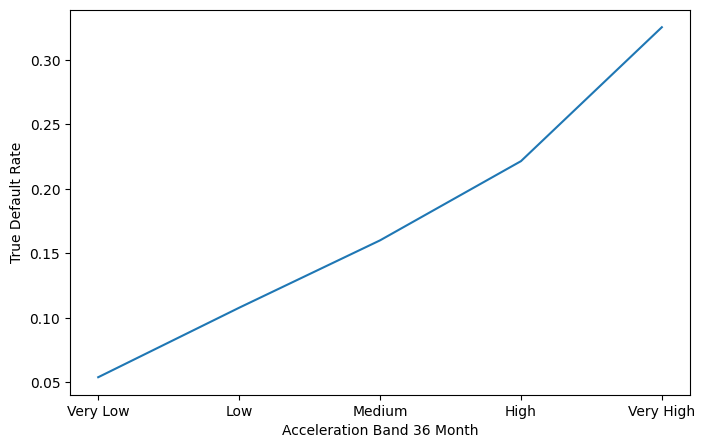

In [55]:
plt.figure(figsize=[8,5])

plt.plot(accel_36_summary["accel_band_36m"],accel_36_summary["actual_default_36m"])

plt.xlabel("Acceleration Band 36 Month")
plt.ylabel("True Default Rate")
plt.show()

We found that higher acceleration bands default more often. The 36-month observed default rate rises from 5.4% in the lowest band to 32.5% in the highest band.

In [56]:
emerging_risk = common_2015[
    (common_2015["pd_12m_adj"] < common_2015["pd_12m_adj"].quantile(0.60))
    & (common_2015["risk_accel_36m"] > common_2015["risk_accel_36m"].quantile(0.80))
].copy()

emerging_risk[[
    "loan_amnt",
    "term",
    "int_rate",
    "grade",
    "sub_grade",
    "annual_inc",
    "dti",
    "fico_range_low",
    "fico_range_high",
    "pd_12m_adj",
    "pd_24m_adj",
    "pd_36m_adj",
    "risk_accel_24m",
    "risk_accel_36m",
    "actual_default_12m",
    "actual_default_24m",
    "actual_default_36m"
]].sort_values("risk_accel_36m", ascending=False).head(20)

,loan_amnt,term,int_rate,grade,sub_grade,annual_inc,dti,fico_range_low,fico_range_high,pd_12m_adj,pd_24m_adj,pd_36m_adj,risk_accel_24m,risk_accel_36m,actual_default_12m,actual_default_24m,actual_default_36m
4404,32000.0,60 months,15.77,D,D1,124000.0,24.82,675.0,679.0,0.046687,0.204579,0.343352,0.157893,0.296666,0,0,0
132268,24000.0,60 months,13.33,C,C3,56000.0,12.52,660.0,664.0,0.044480,0.167837,0.317224,0.123357,0.272744,0,0,1
318639,21000.0,60 months,16.55,D,D2,110000.0,26.41,675.0,679.0,0.043840,0.160988,0.311103,0.117148,0.267263,0,0,0
247658,23975.0,60 months,13.99,C,C4,105000.0,23.82,660.0,664.0,0.047331,0.163758,0.303709,0.116427,0.256378,0,0,0
89074,24000.0,60 months,13.99,C,C4,72000.0,20.78,660.0,664.0,0.046640,0.158396,0.289941,0.111756,0.243301,0,0,0
164573,32000.0,60 months,13.99,C,C4,90000.0,21.33,675.0,679.0,0.043817,0.154102,0.285239,0.110285,0.241422,0,0,0
211500,15000.0,60 months,12.69,C,C2,35712.0,12.77,690.0,694.0,0.042174,0.166750,0.277096,0.124576,0.234923,0,0,0
34533,24000.0,60 months,13.67,C,C4,77000.0,26.98,680.0,684.0,0.045708,0.158560,0.279391,0.112852,0.233683,0,0,0
290060,24000.0,60 months,13.33,C,C3,79000.0,18.96,660.0,664.0,0.046841,0.150015,0.277709,0.103174,0.230868,0,1,1
86903,11200.0,60 months,13.33,C,C3,31000.0,13.63,660.0,664.0,0.045186,0.160308,0.275451,0.115122,0.230265,1,1,1


In [57]:
emerging_risk_summary = (
    emerging_risk
    .groupby(["term", "grade"])
    .agg(
        loans=("risk_accel_36m", "size"),
        avg_pd_12m=("pd_12m_adj", "mean"),
        avg_pd_36m=("pd_36m_adj", "mean"),
        avg_accel_36m=("risk_accel_36m", "mean"),
        actual_default_36m=("actual_default_36m", "mean")
    )
    .reset_index()
    .sort_values(["term", "grade"])
)

emerging_risk_summary

,term,grade,loans,avg_pd_12m,avg_pd_36m,avg_accel_36m,actual_default_36m
0,36 months,A,7,0.031505,0.193514,0.162010,0.142857
1,36 months,B,487,0.040648,0.207534,0.166886,0.205339
2,36 months,C,380,0.043744,0.210404,0.166661,0.260526
3,36 months,D,46,0.044560,0.213775,0.169215,0.304348
4,36 months,E,1,0.044982,0.213370,0.168388,0.000000
5,60 months,B,86,0.039072,0.204125,0.165053,0.255814
6,60 months,C,1724,0.043305,0.211928,0.168623,0.252320
7,60 months,D,388,0.044284,0.214097,0.169813,0.201031
8,60 months,E,13,0.045361,0.211881,0.166521,0.153846


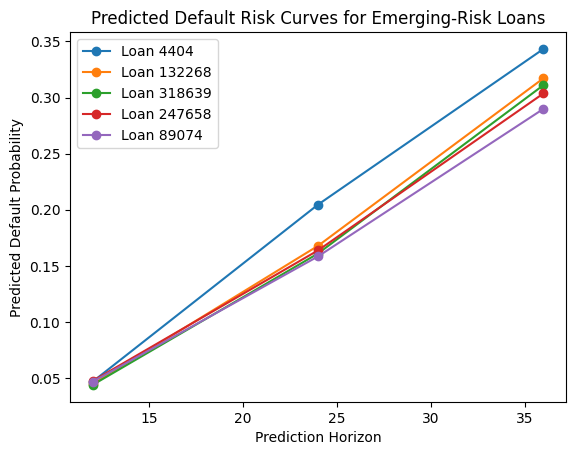

In [58]:
sample_loans = emerging_risk.sort_values("risk_accel_36m", ascending = False).head(5).copy()
sample_loans

for idx, row in sample_loans.iterrows():
    plt.plot(
        [12, 24, 36],
        [row["pd_12m_adj"], row["pd_24m_adj"], row["pd_36m_adj"]],
        marker="o",
        label=f"Loan {idx}"
    )

plt.xlabel("Prediction Horizon")
plt.ylabel("Predicted Default Probability")
plt.title("Predicted Default Risk Curves for Emerging-Risk Loans")
plt.legend()
plt.show()

The emerging-risk rule identifies 3,132 loans with low near-term scores but a 24.0% observed 36-month default rate. This supports a separate watchlist for delayed deterioration.

In [59]:
portfolio_summary = pd.DataFrame(
    {
        "horizon": [12,24,36], 
        "average_predicted_default_rate": [
            common_2015["pd_12m_adj"].mean(),
            common_2015["pd_24m_adj"].mean(),
            common_2015["pd_36m_adj"].mean()
        ],
        "actual_default_rate":[
            common_2015["actual_default_12m"].mean(),
            common_2015["actual_default_24m"].mean(),
            common_2015["actual_default_36m"].mean()
        ]
    }
)
portfolio_summary

,horizon,average_predicted_default_rate,actual_default_rate
0,12,0.048648,0.060480
1,24,0.111859,0.133210
2,36,0.152624,0.173703


Expected-loss acceleration is the increase from 12-month to 36-month expected loss, using the same illustrative 60% LGD.

In [60]:
LGD = 0.60
common_2015["ead"] = common_2015["loan_amnt"]
common_2015["expected_loss_12m"] = common_2015["pd_12m_adj"] * LGD * common_2015["ead"]
common_2015["expected_loss_24m"] = common_2015["pd_24m_adj"] * LGD * common_2015["ead"]
common_2015["expected_loss_36m"] = common_2015["pd_36m_adj"] * LGD * common_2015["ead"]
common_2015["expected_loss_accel_36m"] = common_2015["expected_loss_36m"] - common_2015["expected_loss_12m"]

top_loss_accel = common_2015.sort_values("expected_loss_accel_36m", ascending = False).head(10)
top_loss_accel[[
    "loan_amnt",
    "term",
    "grade",
    "sub_grade",
    "int_rate",
    "annual_inc",
    "dti",
    "pd_12m_adj",
    "pd_36m_adj",
    "risk_accel_36m",
    "expected_loss_12m",
    "expected_loss_36m",
    "expected_loss_accel_36m",
    "actual_default_36m"
]]


,loan_amnt,term,grade,sub_grade,int_rate,annual_inc,dti,pd_12m_adj,pd_36m_adj,risk_accel_36m,expected_loss_12m,expected_loss_36m,expected_loss_accel_36m,actual_default_36m
104263,35000.0,60 months,F,F3,23.99,61140.0,45.77,0.169136,0.552200,0.383064,3551.863296,11596.203350,8044.340053,0
344557,30000.0,60 months,G,G2,25.83,95000.0,19.08,0.159738,0.588506,0.428768,2875.291749,10593.116270,7717.824521,1
59812,33250.0,60 months,E,E1,18.20,98500.0,22.51,0.095682,0.480382,0.384700,1908.856891,9583.630873,7674.773982,1
94310,35000.0,60 months,F,F3,23.99,96654.0,38.99,0.166619,0.523779,0.357160,3498.994098,10999.348741,7500.354643,0
294613,34625.0,60 months,G,G3,25.89,75500.0,20.25,0.177674,0.537837,0.360163,3691.176769,11173.572490,7482.395721,1
98010,35000.0,36 months,E,E2,18.55,110000.0,22.39,0.094038,0.446917,0.352879,1974.798038,9385.261861,7410.463823,1
85574,35000.0,60 months,E,E1,18.25,80000.0,38.60,0.131441,0.474783,0.343342,2760.263967,9970.437059,7210.173091,0
173093,35000.0,60 months,E,E1,18.25,85000.0,30.20,0.080638,0.423778,0.343141,1693.390064,8899.341687,7205.951623,0
264343,35000.0,60 months,F,F2,22.99,130000.0,24.97,0.122201,0.461508,0.339307,2566.215929,9691.658655,7125.442726,0
302979,35000.0,60 months,F,F1,22.99,120000.0,26.27,0.103357,0.441233,0.337875,2170.504608,9265.883302,7095.378694,1


## Monitoring groups

Loans are grouped into high immediate risk, emerging risk, or normal monitoring based on 12-month risk and 36-month acceleration.

In [61]:
pd_12_high = common_2015["pd_12m_adj"].quantile(0.8)
accel_36_high = common_2015["risk_accel_36m"].quantile(0.8)
pd_12_mid = common_2015["pd_12m_adj"].quantile(0.6)

def classify_watchlist(row): 
    if row["pd_12m_adj"] >= pd_12_high: 
        return "High Immediate Risk"
    elif row["pd_12m_adj"] <= pd_12_mid and row["risk_accel_36m"] >= accel_36_high:
        return "Emerging Risk"
    else: 
        return "Normal Monitoring"

common_2015["watchlist_group"] = common_2015.apply(classify_watchlist, axis = 1)

watch_list_summary = common_2015.groupby("watchlist_group").agg(
        loans=("loan_amnt", "count"),
        avg_pd_12m=("pd_12m_adj", "mean"),
        avg_pd_36m=("pd_36m_adj", "mean"),
        avg_accel_36m=("risk_accel_36m", "mean"),
        actual_default_12m=("actual_default_12m", "mean"),
        actual_default_36m=("actual_default_36m", "mean"),
        exposure=("loan_amnt", "sum"),
        expected_loss_36m=("expected_loss_36m", "sum")
).reset_index()

watch_list_summary

,watchlist_group,loans,avg_pd_12m,avg_pd_36m,avg_accel_36m,actual_default_12m,actual_default_36m,exposure,expected_loss_36m
0,Emerging Risk,3132,0.042951,0.211101,0.168149,0.066731,0.239783,5.722712e+07,7.272434e+06
1,High Immediate Risk,84150,0.107086,0.283975,0.176889,0.134938,0.326667,1.320288e+09,2.323965e+08
2,Normal Monitoring,333466,0.033954,0.118928,0.084974,0.041632,0.134481,5.034985e+09,3.613552e+08


# Corrected robustness checks

These checks address sample selection, preprocessing, calibration, feature value, event timing, and watchlist economics.

## Resolved-loan selection

We measure how much of the 2015 portfolio remains after restricting the lifetime model to resolved outcomes.

In [62]:
all_2015 = df[
    pd.to_datetime(df["issue_d"], format="%b-%Y", errors="coerce").dt.year == 2015
].copy()
all_2015["term_num"] = (
    all_2015["term"].astype(str).str.extract(r"(\d+)").astype(float)
)
all_2015["resolved_outcome"] = all_2015["loan_status"].isin(good_status + bad_status)

resolved_outcome_audit = (
    all_2015.groupby("term_num")
    .agg(
        all_loans=("loan_status", "size"),
        resolved_loans=("resolved_outcome", "sum"),
        retained_share=("resolved_outcome", "mean"),
    )
    .reset_index()
)

assert resolved_outcome_audit["retained_share"].between(0, 1).all()
resolved_outcome_audit


,term_num,all_loans,resolved_loans,retained_share
0,36.0,283173,283026,0.999481
1,60.0,137922,92520,0.670814


Almost all 36-month loans are retained, but only 67.1% of 60-month loans are resolved. This selection makes the lifetime results unsuitable as an unbiased estimate of the full 2015 vintage.

## Corrected model comparison

The revised pipelines detect all numeric fields and treat encoded categories as categorical rather than continuous.

In [63]:
from sklearn.base import clone
from sklearn.metrics import brier_score_loss, log_loss


def feature_types(frame):
    numeric = frame.select_dtypes(include=np.number).columns.tolist()
    categorical = frame.select_dtypes(
        include=["object", "string", "category"]
    ).columns.tolist()
    unassigned = sorted(set(frame.columns) - set(numeric) - set(categorical))
    if unassigned:
        raise TypeError(f"Unassigned feature dtypes: {unassigned}")
    return numeric, categorical


def make_logistic_pipeline(frame):
    numeric, categorical = feature_types(frame)
    transformer = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                numeric,
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]),
                categorical,
            ),
        ]
    )
    return Pipeline([
        ("preprocess", transformer),
        ("model", LogisticRegression(max_iter=1000)),
    ])


def make_categorical_hgb_pipeline(frame):
    numeric, categorical = feature_types(frame)
    transformer = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([("imputer", SimpleImputer(strategy="median"))]),
                numeric,
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "ordinal",
                        OrdinalEncoder(
                            handle_unknown="use_encoded_value",
                            unknown_value=-1,
                        ),
                    ),
                ]),
                categorical,
            ),
        ]
    )
    categorical_mask = [False] * len(numeric) + [True] * len(categorical)
    model = HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=200,
        max_leaf_nodes=31,
        min_samples_leaf=100,
        l2_regularization=0.1,
        categorical_features=categorical_mask,
        random_state=42,
    )
    return Pipeline([("preprocess", transformer), ("model", model)])


In [64]:
corrected_lr = make_logistic_pipeline(x_train)
corrected_hgb = make_categorical_hgb_pipeline(x_train)

corrected_lr.fit(x_train, y_train)
corrected_hgb.fit(x_train, y_train)

corrected_lr_pd = corrected_lr.predict_proba(x_test)[:, 1]
corrected_hgb_pd = corrected_hgb.predict_proba(x_test)[:, 1]

corrected_model_comparison = pd.DataFrame([
    {
        "model": "Corrected logistic regression",
        "roc_auc": roc_auc_score(y_test, corrected_lr_pd),
        "average_precision": average_precision_score(y_test, corrected_lr_pd),
        "brier_score": brier_score_loss(y_test, corrected_lr_pd),
        "log_loss": log_loss(y_test, corrected_lr_pd),
    },
    {
        "model": "Categorical-aware histogram boosting",
        "roc_auc": roc_auc_score(y_test, corrected_hgb_pd),
        "average_precision": average_precision_score(y_test, corrected_hgb_pd),
        "brier_score": brier_score_loss(y_test, corrected_hgb_pd),
        "log_loss": log_loss(y_test, corrected_hgb_pd),
    },
])
corrected_model_comparison


,model,roc_auc,average_precision,brier_score,log_loss
0,Corrected logistic regression,0.729498,0.406731,0.144398,0.451786
1,Categorical-aware histogram boosting,0.731404,0.407758,0.144186,0.450598


## Temporal calibration

Training through 2013, calibrating on 2014, and testing on 2015 improves Brier score from 0.1474 to 0.1450. Mean predicted risk moves closer to the observed rate, but underprediction remains in the highest decile.

In [65]:
core_train = data[data["issue_year"] <= 2013].copy()
calibration_2014 = data[data["issue_year"] == 2014].copy()
final_test_2015 = data[data["issue_year"] == 2015].copy()

feature_drop = ["default", "issue_year"]
X_core = core_train.drop(columns=feature_drop)
y_core = core_train["default"]
X_cal = calibration_2014.drop(columns=feature_drop)
y_cal = calibration_2014["default"]
X_final = final_test_2015.drop(columns=feature_drop)
y_final = final_test_2015["default"]

temporal_base_model = make_logistic_pipeline(X_core)
temporal_base_model.fit(X_core, y_core)

raw_cal_pd = temporal_base_model.predict_proba(X_cal)[:, 1]
raw_final_pd = temporal_base_model.predict_proba(X_final)[:, 1]


def clipped_logit(probabilities, epsilon=1e-6):
    p = np.clip(np.asarray(probabilities), epsilon, 1 - epsilon)
    return np.log(p / (1 - p)).reshape(-1, 1)


probability_calibrator = LogisticRegression(C=1e6, max_iter=1000)
probability_calibrator.fit(clipped_logit(raw_cal_pd), y_cal)
calibrated_final_pd = probability_calibrator.predict_proba(
    clipped_logit(raw_final_pd)
)[:, 1]

temporal_calibration_comparison = pd.DataFrame([
    {
        "version": "Uncalibrated",
        "roc_auc": roc_auc_score(y_final, raw_final_pd),
        "average_precision": average_precision_score(y_final, raw_final_pd),
        "brier_score": brier_score_loss(y_final, raw_final_pd),
        "log_loss": log_loss(y_final, raw_final_pd),
        "mean_predicted_pd": raw_final_pd.mean(),
        "observed_default_rate": y_final.mean(),
    },
    {
        "version": "Calibrated on 2014",
        "roc_auc": roc_auc_score(y_final, calibrated_final_pd),
        "average_precision": average_precision_score(y_final, calibrated_final_pd),
        "brier_score": brier_score_loss(y_final, calibrated_final_pd),
        "log_loss": log_loss(y_final, calibrated_final_pd),
        "mean_predicted_pd": calibrated_final_pd.mean(),
        "observed_default_rate": y_final.mean(),
    },
])
temporal_calibration_comparison


,version,roc_auc,average_precision,brier_score,log_loss,mean_predicted_pd,observed_default_rate
0,Uncalibrated,0.723807,0.397904,0.147438,0.460387,0.157233,0.20185
1,Calibrated on 2014,0.723807,0.397904,0.145041,0.454325,0.173373,0.20185


In [66]:
def calibration_by_quantile(actual, predicted, bins=10):
    frame = pd.DataFrame({"actual": np.asarray(actual), "predicted": predicted})
    frame["score_bin"] = pd.qcut(frame["predicted"], q=bins, duplicates="drop")
    return (
        frame.groupby("score_bin", observed=True)
        .agg(
            loans=("actual", "size"),
            mean_predicted_pd=("predicted", "mean"),
            observed_default_rate=("actual", "mean"),
        )
        .assign(
            calibration_gap=lambda x: (
                x["observed_default_rate"] - x["mean_predicted_pd"]
            )
        )
        .reset_index(drop=True)
    )


calibrated_deciles = calibration_by_quantile(y_final, calibrated_final_pd)
calibrated_deciles


,loans,mean_predicted_pd,observed_default_rate,calibration_gap
0,37555,0.033842,0.042258,0.008416
1,37555,0.065842,0.073386,0.007544
2,37554,0.090445,0.098977,0.008532
3,37555,0.113772,0.126774,0.013002
4,37554,0.138359,0.159690,0.021331
5,37555,0.165331,0.186660,0.021328
6,37554,0.196195,0.223119,0.026923
7,37555,0.234919,0.272507,0.037588
8,37554,0.291720,0.344331,0.052611
9,37555,0.403306,0.490800,0.087494


## Value beyond lender-assigned risk

Borrower and loan fields alone reach ROC-AUC 0.716, lender-assigned fields reach 0.710, and the full model reaches 0.729. This shows that both sources add useful information.

In [67]:
lender_assigned_features = ["grade", "sub_grade", "int_rate"]
borrower_only_features = [
    column for column in x_train.columns
    if column not in lender_assigned_features
]

grade_only_model = make_logistic_pipeline(x_train[lender_assigned_features])
borrower_only_model = make_logistic_pipeline(x_train[borrower_only_features])

grade_only_model.fit(x_train[lender_assigned_features], y_train)
borrower_only_model.fit(x_train[borrower_only_features], y_train)

grade_only_pd = grade_only_model.predict_proba(
    x_test[lender_assigned_features]
)[:, 1]
borrower_only_pd = borrower_only_model.predict_proba(
    x_test[borrower_only_features]
)[:, 1]

incremental_value_comparison = pd.DataFrame([
    {
        "feature_set": "Lender-assigned fields only",
        "roc_auc": roc_auc_score(y_test, grade_only_pd),
        "average_precision": average_precision_score(y_test, grade_only_pd),
    },
    {
        "feature_set": "Borrower and loan fields only",
        "roc_auc": roc_auc_score(y_test, borrower_only_pd),
        "average_precision": average_precision_score(y_test, borrower_only_pd),
    },
    {
        "feature_set": "Full corrected model",
        "roc_auc": roc_auc_score(y_test, corrected_lr_pd),
        "average_precision": average_precision_score(y_test, corrected_lr_pd),
    },
])
incremental_value_comparison


,feature_set,roc_auc,average_precision
0,Lender-assigned fields only,0.710231,0.364542
1,Borrower and loan fields only,0.715522,0.397798
2,Full corrected model,0.729498,0.406731


## Censoring-aware hazard benchmark

This model keeps unresolved loans and produces monotone 12-, 24-, and 36-month probabilities. Calibration improves Brier scores, but ranking is weaker than the separate horizon models; event timing remains approximate.

In [68]:
from sklearn.linear_model import SGDClassifier

HAZARD_MAX_MONTHS = 36
HAZARD_INTERVAL_MONTHS = 12
HAZARD_BASE_FEATURES = [column for column in features if column != "issue_d"] + [
    "issue_month"
]

hazard_base = time_df.copy()
hazard_base["loan_id"] = hazard_base.index
hazard_base["issue_year"] = hazard_base["issue_d"].dt.year
hazard_base["issue_month"] = hazard_base["issue_d"].dt.month

data_cutoff = hazard_base["last_pymnt_d"].max()
months_to_cutoff = (
    (data_cutoff.year - hazard_base["issue_d"].dt.year) * 12
    + (data_cutoff.month - hazard_base["issue_d"].dt.month)
)

hazard_base["duration_months"] = hazard_base["months_observed"]
unresolved_mask = ~hazard_base["loan_status"].isin(good_status + bad_status)
hazard_base.loc[unresolved_mask, "duration_months"] = months_to_cutoff[unresolved_mask]
hazard_base["event_default"] = hazard_base["loan_status"].isin(bad_status).astype(int)

hazard_base = hazard_base[
    (hazard_base["issue_year"] <= 2015)
    & hazard_base["duration_months"].notna()
    & (hazard_base["duration_months"] >= 0)
].copy()


def make_person_period(frame, max_months=36, interval_months=12):
    blocks = []
    identity_columns = ["loan_id", "issue_year"]
    for start in range(0, max_months, interval_months):
        end = start + interval_months
        if start == 0:
            at_risk = frame["duration_months"] >= 0
            after_start = frame["duration_months"] >= 0
        else:
            at_risk = frame["duration_months"] > start
            after_start = frame["duration_months"] > start

        block = frame.loc[at_risk, identity_columns + HAZARD_BASE_FEATURES].copy()
        block["interval_end"] = end
        block["hazard_event"] = (
            (frame.loc[at_risk, "event_default"] == 1)
            & after_start.loc[at_risk]
            & (frame.loc[at_risk, "duration_months"] <= end)
        ).astype(int).values
        blocks.append(block)

    result = pd.concat(blocks, ignore_index=True)
    assert result["hazard_event"].isin([0, 1]).all()
    assert result.groupby("loan_id")["hazard_event"].sum().max() <= 1
    return result


hazard_train_long = make_person_period(
    hazard_base[hazard_base["issue_year"] <= 2013]
)
hazard_calibration_long = make_person_period(
    hazard_base[hazard_base["issue_year"] == 2014]
)
hazard_train_long[["interval_end", "hazard_event"]].value_counts().sort_index()


interval_end  hazard_event
12            0               218974
              1                11509
24            0               178251
              1                13300
36            0               127267
              1                 8094
Name: count, dtype: int64

In [69]:
hazard_features = HAZARD_BASE_FEATURES + ["interval_end"]
X_hazard_train = hazard_train_long[hazard_features]
y_hazard_train = hazard_train_long["hazard_event"]

hazard_numeric, hazard_categorical = feature_types(X_hazard_train)
hazard_preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            hazard_numeric,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
            ]),
            hazard_categorical,
        ),
    ]
)

hazard_model = Pipeline([
    ("preprocess", hazard_preprocess),
    (
        "model",
        SGDClassifier(
            loss="log_loss",
            penalty="l2",
            alpha=1e-5,
            max_iter=200,
            tol=1e-3,
            average=True,
            random_state=42,
        ),
    ),
])
hazard_model.fit(X_hazard_train, y_hazard_train)

raw_hazard_calibration_pd = hazard_model.predict_proba(
    hazard_calibration_long[hazard_features]
)[:, 1]
hazard_probability_calibrator = LogisticRegression(C=1e6, max_iter=1000)
hazard_probability_calibrator.fit(
    clipped_logit(raw_hazard_calibration_pd),
    hazard_calibration_long["hazard_event"],
)


,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1000000.0
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [70]:
hazard_score_base = common_2015[HAZARD_BASE_FEATURES].copy()
raw_interval_hazards = []
calibrated_interval_hazards = []

for interval_end in [12, 24, 36]:
    scoring_frame = hazard_score_base.copy()
    scoring_frame["interval_end"] = interval_end
    raw_hazard = hazard_model.predict_proba(scoring_frame)[:, 1]
    calibrated_hazard = hazard_probability_calibrator.predict_proba(
        clipped_logit(raw_hazard)
    )[:, 1]
    raw_interval_hazards.append(raw_hazard)
    calibrated_interval_hazards.append(calibrated_hazard)

raw_interval_hazards = np.column_stack(raw_interval_hazards)
calibrated_interval_hazards = np.column_stack(calibrated_interval_hazards)
raw_cumulative_pd = 1 - np.cumprod(1 - raw_interval_hazards, axis=1)
calibrated_cumulative_pd = 1 - np.cumprod(
    1 - calibrated_interval_hazards, axis=1
)

hazard_results = pd.DataFrame(
    {
        "pd_12m_hazard_raw": raw_cumulative_pd[:, 0],
        "pd_24m_hazard_raw": raw_cumulative_pd[:, 1],
        "pd_36m_hazard_raw": raw_cumulative_pd[:, 2],
        "pd_12m_hazard": calibrated_cumulative_pd[:, 0],
        "pd_24m_hazard": calibrated_cumulative_pd[:, 1],
        "pd_36m_hazard": calibrated_cumulative_pd[:, 2],
    },
    index=common_2015.index,
)

hazard_performance = []
for horizon in [12, 24, 36]:
    actual = common_2015[f"actual_default_{horizon}m"]
    raw_predicted = hazard_results[f"pd_{horizon}m_hazard_raw"]
    predicted = hazard_results[f"pd_{horizon}m_hazard"]
    hazard_performance.append(
        {
            "horizon": horizon,
            "loans": len(actual),
            "default_rate": actual.mean(),
            "roc_auc": roc_auc_score(actual, predicted),
            "average_precision": average_precision_score(actual, predicted),
            "raw_brier_score": brier_score_loss(actual, raw_predicted),
            "brier_score": brier_score_loss(actual, predicted),
            "raw_mean_predicted_pd": raw_predicted.mean(),
            "mean_predicted_pd": predicted.mean(),
        }
    )

hazard_performance = pd.DataFrame(hazard_performance)
assert (hazard_results["pd_24m_hazard"] >= hazard_results["pd_12m_hazard"]).all()
assert (hazard_results["pd_36m_hazard"] >= hazard_results["pd_24m_hazard"]).all()
hazard_performance


,horizon,loans,default_rate,roc_auc,average_precision,raw_brier_score,brier_score,raw_mean_predicted_pd,mean_predicted_pd
0,12,420748,0.060480,0.675566,0.115544,0.057443,0.055527,0.021054,0.059766
1,24,420748,0.133210,0.667711,0.228669,0.119731,0.110896,0.044699,0.120636
2,36,420748,0.173703,0.666356,0.285996,0.147896,0.136426,0.071106,0.182174


## Economic watchlist

Using illustrative assumptions of 60% LGD, 15% intervention effectiveness, a $50 review cost, and 20% capacity, the rule selects 84,149 loans and estimates $40.5M in net benefit. This is a scenario, not a deployment forecast.

In [71]:
def economic_watchlist(
    frame,
    pd_column="pd_36m_adj",
    lgd=0.60,
    intervention_effectiveness=0.15,
    review_cost_per_loan=50.0,
    capacity_share=0.20,
):
    if not 0 <= intervention_effectiveness <= 1:
        raise ValueError("intervention_effectiveness must be between 0 and 1")
    if not 0 < capacity_share <= 1:
        raise ValueError("capacity_share must be in (0, 1]")

    result = frame.copy()
    result["scenario_expected_loss"] = (
        result[pd_column] * lgd * result["loan_amnt"]
    )
    result["expected_loss_avoided"] = (
        result["scenario_expected_loss"] * intervention_effectiveness
    )
    result["scenario_net_benefit"] = (
        result["expected_loss_avoided"] - review_cost_per_loan
    )

    capacity = max(1, int(np.floor(len(result) * capacity_share)))
    positive_value = result[result["scenario_net_benefit"] > 0]
    selected_index = positive_value.nlargest(
        min(capacity, len(positive_value)), "scenario_net_benefit"
    ).index
    result["economic_watchlist"] = result.index.isin(selected_index)
    result["selected_expected_loss_avoided"] = np.where(
        result["economic_watchlist"], result["expected_loss_avoided"], 0.0
    )
    result["selected_net_benefit"] = np.where(
        result["economic_watchlist"], result["scenario_net_benefit"], 0.0
    )
    return result


economic_results = economic_watchlist(common_2015)
economic_watchlist_summary = (
    economic_results.groupby("economic_watchlist")
    .agg(
        loans=("loan_amnt", "size"),
        exposure=("loan_amnt", "sum"),
        mean_pd_36m=("pd_36m_adj", "mean"),
        actual_default_36m=("actual_default_36m", "mean"),
        selected_expected_loss_avoided=("selected_expected_loss_avoided", "sum"),
        selected_net_benefit=("selected_net_benefit", "sum"),
    )
    .reset_index()
)
economic_watchlist_summary


,economic_watchlist,loans,exposure,mean_pd_36m,actual_default_36m,selected_expected_loss_avoided,selected_net_benefit
0,False,336599,4.407584e+09,0.125840,0.143066,0.000000e+00,0.000000e+00
1,True,84149,2.004917e+09,0.259761,0.296248,4.468286e+07,4.047541e+07


## Takeaways

- Use the model for ranking and monitoring, not as a production probability estimate yet.
- Improve event timing and validate results across multiple vintages.
- Add post-origination behavior for longer-horizon deterioration.
- Replace the example LGD, intervention, cost, and capacity inputs with approved business assumptions.